In [215]:
import numpy as np
import mne
from pathlib import Path

import matplotlib.pyplot as plt

from scipy.signal import resample_poly, find_peaks, welch
from scipy.stats import gaussian_kde

In [214]:
dataset_path = Path("BCI4_2a")
subject_id = 3

In [216]:
def read_subject_epochs(subject_id: int|list, dataset_path: Path,
                        is_train: bool = True,
                        l_freq: float = 4.0,
                        h_freq: float = 37.0,
                        tmin: float = -0.5,
                        tmax: float = 4.5):
    """
    Загружает EEG одного субъекта BCI IV 2a и возвращает:
    epochs, X, y, label_names
    """
    train_eval_label = "T" if is_train else "E"

    if type(subject_id) == int:
        subject_prefix = f"A0{subject_id}"
        subject_training_data_path = dataset_path / (subject_prefix + f"{train_eval_label}.gdf")
        raw = mne.io.read_raw_gdf(subject_training_data_path, preload=True)
    else:
        raw = []
        for i in subject_id:
            subject_prefix = f"A0{i}"
            subject_training_data_path = dataset_path / (subject_prefix + f"{train_eval_label}.gdf")
            raw.append(mne.io.read_raw_gdf(subject_training_data_path, preload=True))
        raw = mne.concatenate_raws(raw)
    bci_channels = [
    'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2',
    'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz'
    ]

    # Создаем соответствие с индексами каналов в данных
    # (если каналы называются иначе)
    if raw.ch_names[0].startswith('EEG'):
        rename_dict = dict()
        for key, value in zip(raw.ch_names[:-3], bci_channels):
            rename_dict[key] = value
        raw.rename_channels(rename_dict)
    raw.filter(l_freq, h_freq, verbose=False)
    raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])

    raw.set_montage('standard_1020')

    events, event_dict = mne.events_from_annotations(raw)

    event_id = {
        "left": event_dict["769"],
        "right": event_dict["770"],
        "foot": event_dict["771"],
        "tongue": event_dict["772"],
    }

    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=tmin,
        tmax=tmax,
        baseline=None,
        preload=True,
        reject_by_annotation=True,
        verbose=False
    )

    X = epochs.get_data()  # (n_epochs, n_channels, n_times)
    y_raw = epochs.events[:, -1]

    label_map = {
        event_dict["769"]: 0,
        event_dict["770"]: 1,
        event_dict["771"]: 2,
        event_dict["772"]: 3,
    }
    inv_label_map = {0: "left", 1: "right", 2: "foot", 3: "tongue"}

    y = np.array([label_map[i] for i in y_raw])

    return epochs, X, y, inv_label_map

In [217]:
epochs, X, y, inv_label_map = read_subject_epochs(subject_id, dataset_path, l_freq=1, h_freq=40)

Extracting GDF parameters from BCI4_2a/A03T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 660529  =      0.000 ...  2642.116 secs...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]


In [174]:
ep_list[1]

<Epochs | 288 events (all good), -0.5 – 4.5 s (baseline off), ~60.5 MiB, data loaded,
 'left': 72
 'right': 72
 'foot': 72
 'tongue': 72>

In [175]:
epochs

<Epochs | 2304 events (all good), -0.5 – 4.5 s (baseline off), ~483.8 MiB, data loaded,
 'left': 576
 'right': 576
 'foot': 576
 'tongue': 576>

In [176]:
from mne.time_frequency import psd_array_welch

In [177]:
fmin, fmax = 2, 40  # Диапазон частот
n_fft = 256
s_freq = 250


In [178]:
# freqs = np.arange(n_fft // 2 + 1, dtype=float) * (s_freq / n_fft)
# freq_mask = (freqs >= fmin) & (freqs <= fmax)
# freqs = freqs[freq_mask]
# len(freqs)

In [179]:
# psds, freqs = psd_array_welch(X, s_freq, fmin=fmin, fmax=fmax, n_fft=n_fft, n_jobs=14)
spectrum = epochs.compute_psd(method="welch", fmin=fmin, fmax=fmax, n_fft=n_fft, n_jobs=14)


Effective window size : 1.024 (s)


[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done   4 out of  14 | elapsed:    2.4s remaining:    6.0s
[Parallel(n_jobs=14)]: Done   7 out of  14 | elapsed:    2.5s remaining:    2.5s
[Parallel(n_jobs=14)]: Done  10 out of  14 | elapsed:    2.7s remaining:    1.1s
[Parallel(n_jobs=14)]: Done  14 out of  14 | elapsed:    2.7s finished


Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


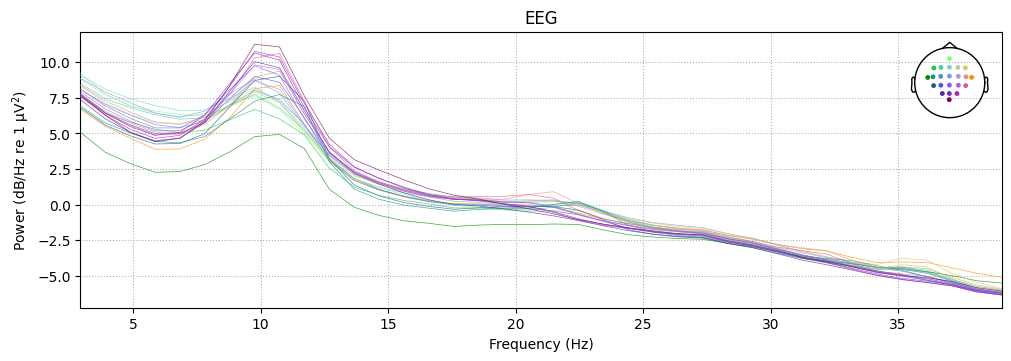

In [180]:
spectrum.plot()

In [181]:
spectrum.get_data()

array([[[4.56164912e-12, 7.51107332e-12, 8.03184902e-12, ...,
         7.30100919e-13, 1.78375207e-13, 7.91036917e-14],
        [7.98127465e-13, 5.33431756e-12, 6.00627647e-12, ...,
         6.78398918e-13, 1.80582137e-13, 4.52825893e-14],
        [4.56112871e-13, 6.17179315e-12, 8.62396972e-12, ...,
         6.25180519e-13, 1.46635747e-13, 5.49716743e-14],
        ...,
        [2.94209275e-12, 3.69110174e-12, 5.41190704e-12, ...,
         2.45391922e-13, 1.72453360e-13, 7.33330033e-14],
        [2.55727073e-12, 3.49244858e-12, 4.60858022e-12, ...,
         1.93306634e-13, 1.46420991e-13, 6.58124147e-14],
        [2.66182581e-12, 2.63258763e-12, 3.83096501e-12, ...,
         2.17509288e-13, 1.96258291e-13, 6.03089630e-14]],

       [[6.07895325e-12, 4.31173675e-12, 3.88139691e-12, ...,
         3.05317307e-13, 1.52065698e-13, 1.76154502e-13],
        [1.06986196e-11, 4.42678877e-12, 3.92854715e-12, ...,
         3.19493981e-13, 8.06035599e-14, 1.52050428e-13],
        [9.65862583e-12, 

In [182]:
spectrum.freqs

array([ 2.9296875,  3.90625  ,  4.8828125,  5.859375 ,  6.8359375,
        7.8125   ,  8.7890625,  9.765625 , 10.7421875, 11.71875  ,
       12.6953125, 13.671875 , 14.6484375, 15.625    , 16.6015625,
       17.578125 , 18.5546875, 19.53125  , 20.5078125, 21.484375 ,
       22.4609375, 23.4375   , 24.4140625, 25.390625 , 26.3671875,
       27.34375  , 28.3203125, 29.296875 , 30.2734375, 31.25     ,
       32.2265625, 33.203125 , 34.1796875, 35.15625  , 36.1328125,
       37.109375 , 38.0859375, 39.0625   ])

In [183]:
from scipy.stats import ttest_ind
from typing import Dict, Tuple

In [184]:
def group_by_bands(spectrum: mne.time_frequency.EpochsSpectrum, bands: Dict[str, Tuple[float, float]]):
    band_powers = dict()
    for band_name, (f_min, f_max) in bands.items():
        band_powers[band_name] = np.mean(spectrum.get_data(fmin=f_min, fmax=f_max), axis=2)
    
    return band_powers

In [185]:
bands = {'Delta (0-4 Hz)': (0, 4), 'Theta (4-8 Hz)': (4, 8),
         'Alpha (8-12 Hz)': (8, 12), 'Beta (12-30 Hz)': (12, 30),
         'Gamma (30-45 Hz)': (30, 45)}

In [186]:
band_powers_left = group_by_bands(spectrum['left'], bands)
band_powers_right = group_by_bands(spectrum['foot'], bands)

In [187]:
band_powers_left

{'Delta (0-4 Hz)': array([[1.37456786e-11, 1.33700570e-11, 1.31967188e-11, ...,
         6.56964087e-12, 5.94776284e-12, 7.57306080e-12],
        [1.09488288e-11, 7.26096772e-12, 1.10276142e-11, ...,
         8.50155254e-12, 7.91550733e-12, 7.09871803e-12],
        [1.04479080e-11, 6.33961464e-12, 6.02981995e-12, ...,
         2.55077766e-12, 2.27341074e-12, 2.80404369e-12],
        ...,
        [7.60901729e-12, 6.48697379e-12, 7.96352595e-12, ...,
         1.18262415e-11, 1.11684218e-11, 1.01938753e-11],
        [1.10835213e-11, 4.79575813e-12, 7.64487159e-12, ...,
         9.05263857e-12, 8.95829645e-12, 9.32371043e-12],
        [1.19787970e-11, 5.16244895e-12, 7.18936579e-12, ...,
         1.00674376e-11, 1.06563371e-11, 1.69736342e-11]], shape=(576, 22)),
 'Theta (4-8 Hz)': array([[6.12249502e-12, 5.98466673e-12, 6.30362945e-12, ...,
         7.08435042e-12, 5.88553118e-12, 4.04905950e-12],
        [4.03727694e-12, 2.58639784e-12, 3.20222865e-12, ...,
         1.48761613e-12, 1.225

In [188]:
def statistical_test(band_powers_1, band_powers_2, stat_test_func, stat_test_func_kwargs=dict()):
    result_dict = dict()
    p_value_dict = dict()
    statistic_dict = dict()

    for (band, epoch_channel_power_array_1), epoch_channel_power_array_2 in zip(band_powers_1.items(), band_powers_2.values()):
        channel_epoch_power_array_1 = np.swapaxes(epoch_channel_power_array_1, 0, 1)
        channel_epoch_power_array_2 = np.swapaxes(epoch_channel_power_array_2, 0, 1)
        result_dict[band] = list()
        p_value_dict[band] = list()
        statistic_dict[band] = list()
        for channel, (epoch_power_array_1, epoch_power_array_2) in enumerate(zip(channel_epoch_power_array_1, channel_epoch_power_array_2)):
            result = ttest_ind(epoch_power_array_1, epoch_power_array_2, **stat_test_func_kwargs)
            result_dict[band].append(result)
            p_value_dict[band].append(result.pvalue)
            statistic_dict[band].append(result.statistic)
            if result.pvalue < 0.05:
                 print(result.pvalue, band)
        result_dict[band] = np.array(result_dict[band])
        p_value_dict[band] = np.array(p_value_dict[band])
        statistic_dict[band] = np.array(statistic_dict[band])

    return result_dict, p_value_dict, statistic_dict

In [189]:
result_dict, p_value_dict, statistic_dict = statistical_test(band_powers_left, band_powers_right, stat_test_func=ttest_ind, stat_test_func_kwargs = {"equal_var": False})

0.011228941109428231 Delta (0-4 Hz)
0.0002492456575094553 Delta (0-4 Hz)
0.0008734383918468789 Delta (0-4 Hz)
0.004109066021788005 Delta (0-4 Hz)
4.0231434872511836e-05 Delta (0-4 Hz)
0.016496613031012464 Alpha (8-12 Hz)
0.002089795694406669 Alpha (8-12 Hz)
0.04314491950040049 Alpha (8-12 Hz)
0.0022757884643538856 Alpha (8-12 Hz)
0.010435463123020324 Alpha (8-12 Hz)


In [190]:
epochs.info["dig"]
pass

In [191]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

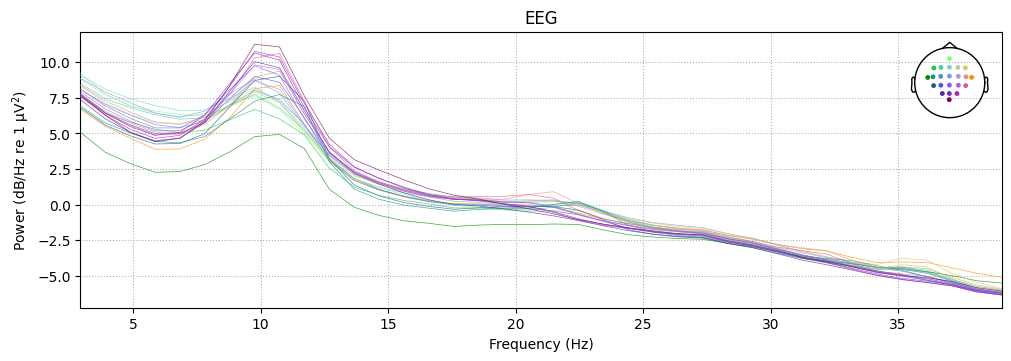

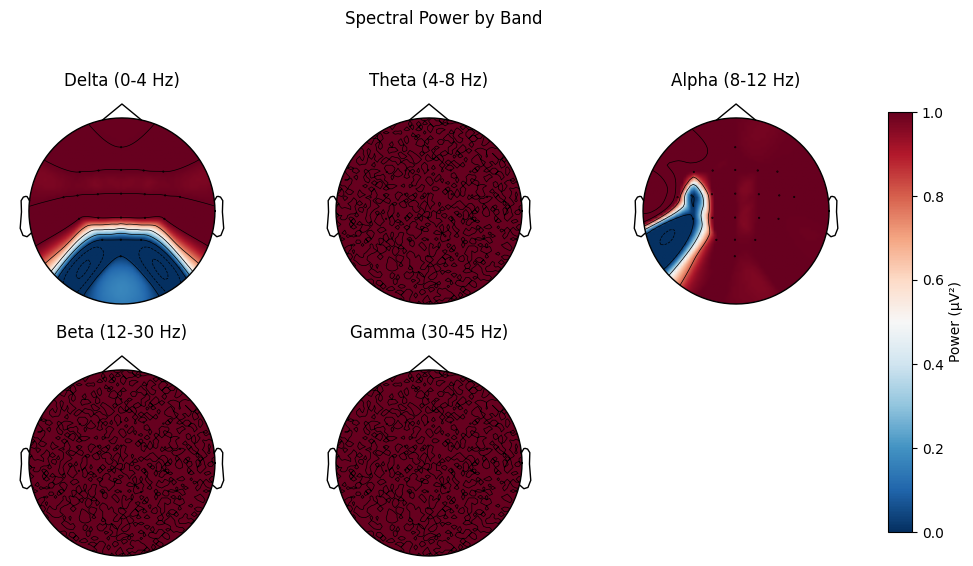

In [192]:
def plot_stattest_result(data):
    fig = plt.figure(figsize=(12, 6))
    gs = gridspec.GridSpec(2, 3, figure=fig)
    gs.update(right=0.85)  # место под colorbar

    # Единый vmin/vmax для сравнения
    all_vals = np.concatenate([np.atleast_1d(v).ravel() for v in data.values()])
    vlim = (np.percentile(all_vals, 5), np.percentile(all_vals, 95))
    vlim = (0, 1)


    for idx, (name, _) in enumerate(bands.items()):
        ax = fig.add_subplot(gs[idx // 3, idx % 3])
        data[name] = np.array(list(map(lambda x: 0 if x < 0.005 else 1, data[name])))
        im, cntr = mne.viz.plot_topomap(
            data[name], pos=epochs.info, axes=ax, show=False,
            vlim=vlim, cmap='RdBu_r'
        )
        ax.set_title(name)

    # Общий colorbar
    cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Power (µV²)')
    plt.suptitle('Spectral Power by Band', y=1.02)
    plt.show()

plot_stattest_result(p_value_dict)

In [193]:
from scipy.stats import mannwhitneyu

In [219]:
spectrum.freqs

array([ 2.9296875,  3.90625  ,  4.8828125,  5.859375 ,  6.8359375,
        7.8125   ,  8.7890625,  9.765625 , 10.7421875, 11.71875  ,
       12.6953125, 13.671875 , 14.6484375, 15.625    , 16.6015625,
       17.578125 , 18.5546875, 19.53125  , 20.5078125, 21.484375 ,
       22.4609375, 23.4375   , 24.4140625, 25.390625 , 26.3671875,
       27.34375  , 28.3203125, 29.296875 , 30.2734375, 31.25     ,
       32.2265625, 33.203125 , 34.1796875, 35.15625  , 36.1328125,
       37.109375 , 38.0859375, 39.0625   ])

0.011228446006843834 Delta (0-4 Hz)
0.00024903246393417043 Delta (0-4 Hz)
0.0008729957631600312 Delta (0-4 Hz)
0.00410798682794409 Delta (0-4 Hz)
3.9993536162465664e-05 Delta (0-4 Hz)
0.01648828296031683 Alpha (8-12 Hz)
0.002085595506000637 Alpha (8-12 Hz)
0.043142743234294664 Alpha (8-12 Hz)
0.0022710690832384293 Alpha (8-12 Hz)
0.010433733436485789 Alpha (8-12 Hz)


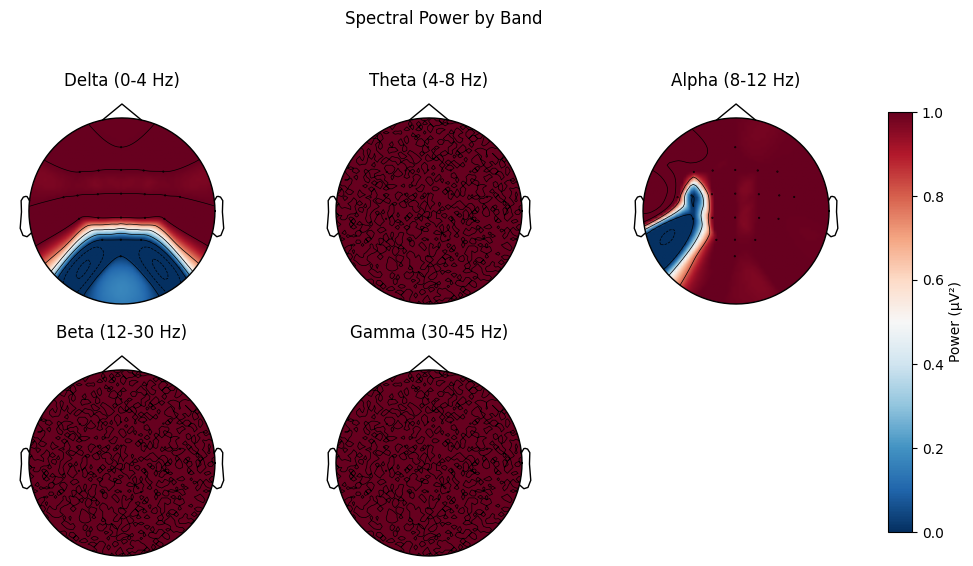

In [194]:
result_dict, p_value_dict, statistic_dict = statistical_test(band_powers_left, band_powers_right, stat_test_func=mannwhitneyu)
plot_stattest_result(p_value_dict)

In [195]:
adj = mne.channels.find_ch_adjacency(epochs.info, 'eeg')

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 22


In [196]:
adj[1]

['Fz',
 'FC3',
 'FC1',
 'FCz',
 'FC2',
 'FC4',
 'C5',
 'C3',
 'C1',
 'Cz',
 'C2',
 'C4',
 'C6',
 'CP3',
 'CP1',
 'CPz',
 'CP2',
 'CP4',
 'P1',
 'Pz',
 'P2',
 'POz']

In [197]:
print(adj[0].toarray()[4])

[1 0 0 1 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0]


In [198]:
left_sample, right_sample = spectrum['left'], spectrum['right']

In [199]:
left_sample.shape

(576, 22, 38)

In [200]:
time_adjacency = mne.stats.combine_adjacency(
    left_sample.shape[2], adj[0]
)

In [201]:
time_adjacency

<COOrdinate sparse array of dtype 'float64'
	with 6492 stored elements and shape (836, 836)>

In [202]:
print(time_adjacency[88])

<COOrdinate sparse array of dtype 'float64'
	with 8 stored elements and shape (836,)>
  Coords	Values
  (66,)	1.0
  (110,)	1.0
  (89,)	1.0
  (90,)	1.0
  (91,)	1.0
  (92,)	1.0
  (93,)	1.0
  (88,)	1.0


In [203]:
left_sample.data

array([[[1.63681261e-11, 1.11232311e-11, 5.27168385e-12, ...,
         3.77419295e-13, 2.01872987e-13, 9.96262063e-14],
        [1.67258589e-11, 1.00142551e-11, 5.04387930e-12, ...,
         4.33414843e-13, 1.66038979e-13, 4.32542058e-14],
        [1.56684255e-11, 1.07250122e-11, 5.05478455e-12, ...,
         3.63627113e-13, 1.14792968e-13, 5.06411709e-14],
        ...,
        [7.18714919e-12, 5.95213255e-12, 2.80981054e-12, ...,
         9.96487382e-14, 3.91194001e-14, 3.66893295e-14],
        [6.47504236e-12, 5.42048331e-12, 2.41041174e-12, ...,
         8.47589412e-14, 4.16142092e-14, 4.09366477e-14],
        [8.29839203e-12, 6.84772958e-12, 2.50144977e-12, ...,
         9.15151060e-14, 2.50652791e-14, 5.56794804e-14]],

       [[8.60213970e-12, 1.32955179e-11, 4.38219746e-12, ...,
         6.84628401e-13, 2.20545029e-13, 4.65820613e-14],
        [7.11692406e-12, 7.40501138e-12, 2.43632265e-12, ...,
         5.57433739e-13, 2.54706048e-13, 1.00270300e-13],
        [1.06764975e-11, 

In [204]:
from matplotlib.pylab import axes
left_sample_reshaped = left_sample.data.transpose(0, 2, 1)
right_sample_reshaped = right_sample.data.transpose(0, 2, 1)
left_sample_reshaped.shape

(576, 38, 22)

In [210]:
f_thresh=dict(start=0, step=0.2)

In [ ]:
import scipy
p_unc = 0.005
dfn = 1  # степени свободы числителя (между группами) = количество групп - 1
dfd = (left_sample_reshaped.shape[0] + right_sample_reshaped.shape[0] - dfn*2)  # внутригрупповые степени свободы
f_thresh = scipy.stats.f.ppf(1 - p_unc, dfn, dfd)
f_thresh

np.float64(3.8495576594362486)

In [211]:
F_obs, clusters, cluster_pv, H0 = mne.stats.permutation_cluster_test([left_sample_reshaped, right_sample_reshaped], threshold=f_thresh, n_permutations=4000,
                                   adjacency=time_adjacency, seed = 42, n_jobs = 5, check_disjoint=True, out_type='mask')
#significant_points = cluster_pv.reshape(F_obs.shape).T < 0.05
#print(str(significant_points.sum()) + " points selected by TFCE ...")

stat_fun(H1): min=1.2634464691735996e-05 max=13.27188753024801
No disjoint adjacency sets found
Running initial clustering …
Using 67 thresholds from 0.00 to 13.20 for TFCE computation (h_power=2.00, e_power=0.50)
Found 836 clusters


  0%|          | Permuting : 0/3999 [00:00<?,       ?it/s]

In [209]:
cluster_pv

array([0.78625, 0.6985 , 0.52725])

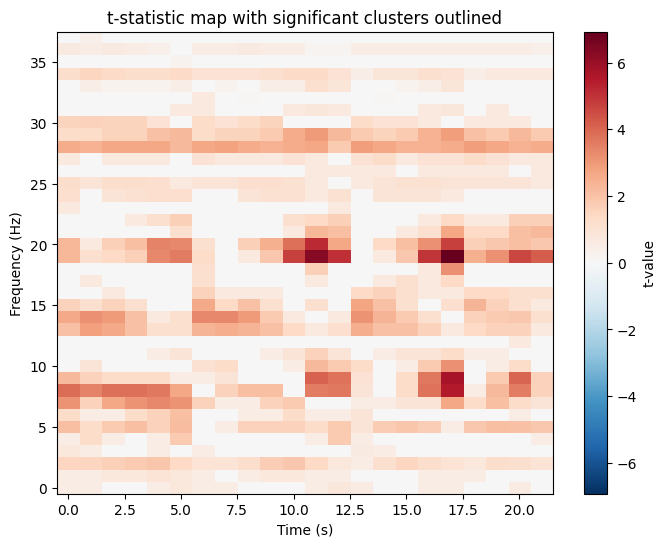

In [212]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Выбираем значимые кластеры (p < 0.05)
significant_clusters = [mask for mask, p in zip(clusters, cluster_pv) if p < 0.05]

# Создаём общую маску значимых точек (объединение всех значимых кластеров)
sig_mask = np.zeros_like(F_obs, dtype=bool)
for mask in significant_clusters:
    sig_mask |= mask

# Настройка фигуры
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Отрисовка карты t-статистики
# Для двустороннего теста используем дивергирующую цветовую карту
# Симметричная нормализация вокруг нуля
vmax = max(abs(F_obs.min()), abs(F_obs.max()))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

im = ax.imshow(F_obs, origin='lower', aspect='auto', cmap='RdBu_r', norm=norm)
               #,extent=[times[0], times[-1], freqs[0], freqs[-1]])
plt.colorbar(im, ax=ax, label='t-value')

# Наложение контуров значимых кластеров
for mask in significant_clusters:
    # contour ожидает массив, где 1 = внутри, 0 = снаружи
    # Используем уровни [0.5] для обводки границы
    ax.contour(mask, levels=[0.5], colors='black', linewidths=1)
               #,extent=[times[0], times[-1], freqs[0], freqs[-1]])

# Оформление осей
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('t-statistic map with significant clusters outlined')

#plt.tight_layout()
plt.show()

In [ ]:
cluster_pv

array([1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 0.99975, 1.     , 0.99975,
       0.99975, 1.     , 0.999  , 0.999  , 1.     , 0.99975, 0.99975,
       1.     , 0.999  , 0.9995 , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       0.99975, 0.999  , 1.     , 1.     , 1.     , 1.     , 0.99975,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.  

In [ ]:
cluster_pv

array([0.0085, 0.124 , 0.037 ])

In [ ]:
H0.shape

(4000,)

In [ ]:
clusters[0]

(array([7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9]),
 array([10, 11, 12, 16, 17, 20,  5, 10, 11, 12, 16, 17, 20, 11, 12, 16, 17]))

In [ ]:
print(min(cluster_pv))

0.466


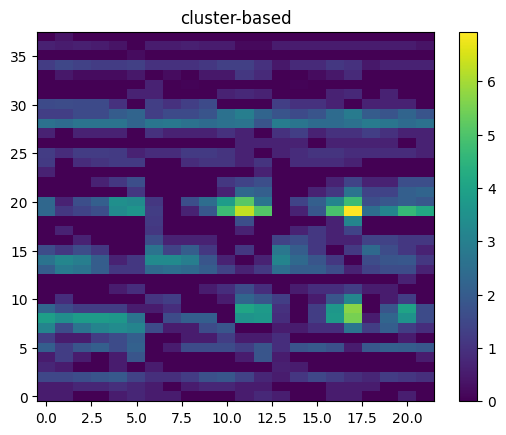

In [213]:
plt.imshow(F_obs, origin='lower', aspect='auto')
plt.colorbar()
plt.title('cluster-based')
plt.show()

In [ ]:
choosen = []
for i, val in enumerate(cluster_pv):
    if val < 0.05: choosen.append((i, val))

choosen

[(0, np.float64(0.0085)), (2, np.float64(0.037))]

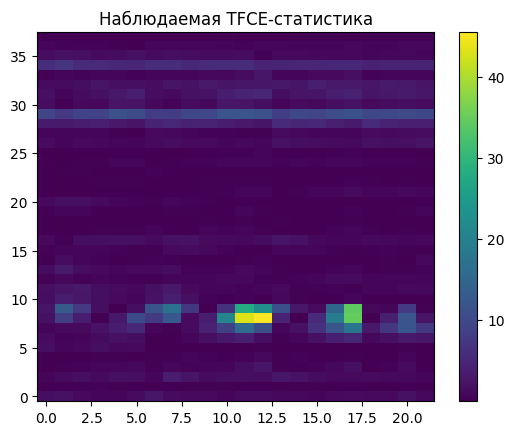

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(F_obs, origin='lower', aspect='auto')
plt.colorbar()
plt.title("Наблюдаемая TFCE-статистика")
plt.show()

In [ ]:
plt.imshow(F_obs1, origin='lower', aspect='auto')
plt.colorbar()
plt.title("Наблюдаемая TFCE-статистика")
plt.show()

NameError: name 'F_obs1' is not defined

In [ ]:
choosen = []
for i, val in enumerate(cluster_pv1):
    if val < 0.95: choosen.append((i, val))

choosen

[(182, np.float64(0.8265)),
 (183, np.float64(0.93075)),
 (189, np.float64(0.855)),
 (199, np.float64(0.938)),
 (204, np.float64(0.8035)),
 (205, np.float64(0.86375)),
 (211, np.float64(0.765)),
 (233, np.float64(0.847)),
 (235, np.float64(0.93875)),
 (236, np.float64(0.94625)),
 (254, np.float64(0.93875)),
 (257, np.float64(0.93225)),
 (258, np.float64(0.895)),
 (259, np.float64(0.85475)),
 (261, np.float64(0.91075)),
 (262, np.float64(0.8635)),
 (263, np.float64(0.93875)),
 (292, np.float64(0.9425)),
 (299, np.float64(0.9455))]

In [ ]:
cluster_pv1

array([1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 0.99625, 1.     ,
       1.     , 1.     , 1.     , 0.99975, 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       1.     , 1.     , 1.     , 1.     , 0.999  , 1.     , 1.     ,
       0.999  , 0.998  , 0.99625, 1.     , 1.     , 1.     , 1.     ,
       0.99975, 0.99

In [ ]:
clusters[192]

IndexError: list index out of range

In [ ]:
clusters[1]

(array([0]), array([1]))

In [ ]:
set([17,  5,  9, 10, 11, 12, 15, 16, 17, 19, 20, 21,  5, 10, 11, 12, 15,
        16, 17, 20, 10, 11, 12, 16, 17, 20])

{5, 9, 10, 11, 12, 15, 16, 17, 19, 20, 21}